In [ ]:
from collections import Counter, defaultdict
from community import community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
import numpy as np
import random
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else '.')
from got_style import (
    apply_style, got_title, save_fig,
    PALETTE, diverging_colors, categorical_colors, distinctive_colors,
)
apply_style()

random.seed(42); np.random.seed(42)
### Main Question: Can we predict affilitations through Louvian sepeartion? If not, what other factors does then descripe the network

# Graph Analysis

## Data processing design choices

**Assigning one allegiance per character.** 82.2% of characters carry at least one allegiance, but many list several and the wiki does not rank them. To analyse allegiance as a single label, we assign each character to their *largest* allegiance (the one with the most members across the whole dataset), breaking ties by the wiki's listed order. This is a deliberate simplification with a known bias: routing ambiguous multi-allegiance characters into the biggest factions inflates the apparent size and cohesion of large houses and pushes the later community-versus-allegiance agreement upward. We keep the rule for clarity but read the agreement scores as an upper bound, not a neutral measurement.

**Merging the Baratheon labels.** The wiki splits House Baratheon into three labels (Baratheon, Baratheon of Dragonstone, Baratheon of King's Landing). We merge them into one House Baratheon, since otherwise a major faction would be split into three under-represented fragments.

## Research question

### Main question: can we predict affiliations through Louvain separation? If not, what other factors describe the network?

### This section contains

1. **Exploration of the largest allegiances** on the raw tally: houses, orders, factions and the occasional person.
2. **Looking at the network coloured by allegiance:** overall structure and visible tendencies.
3. **Louvain groups:** how the network partitions, and what the modularity says.
4. **True labels vs Louvain groups:** accuracy, ARI, NMI, homogeneity, completeness.
5. **What the communities really are:** the two-sided structure (separate books vs one fragmented main story).

## 1 Preliminary dataoverview of the changes.

In [80]:
#Load v3 + build network 
df = pd.read_csv('csvs/characters_enriched_v3.csv').fillna('')
display(df.head())

#Mergin baratheons 
BARATHEON_VARIANTS = {
      'House_Baratheon_of_Dragonstone':    'House_Baratheon',
      "House_Baratheon_of_King's_Landing": 'House_Baratheon',
  }

def normalize_baratheon(s): 
      parts = [BARATHEON_VARIANTS.get(p.strip(), p.strip())
               for p in s.split(';') if p.strip()]
      seen = set(); out = []
      for p in parts:
          if p not in seen:
              seen.add(p); out.append(p)
      return ';'.join(out)

df['allegiance'] = df['allegiance'].apply(normalize_baratheon)
valid_ids = set(df['ID'])

# Undirected edge A-B iff B is in A's affiliated list.
# nx.Graph is undirected and dedups, so no explicit edge set is needed.
G = nx.Graph()
G.add_nodes_from(df['ID'])
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in (t.strip() for t in row['affiliated'].split(';')):
        if tgt and tgt != src and tgt in valid_ids:
            G.add_edge(src, tgt)

LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

#Global allegiance counts
multi_counts = Counter()
for _, row in df.iterrows():
    if not row['allegiance']:
        continue
    for h in row['allegiance'].split(';'):
        h = h.strip()
        if h:
            multi_counts[h] += 1


# Primary house = the entry with the highest global membership count
# (Ties broken by the wiki's listed order: first-listed wins on a tie.)
def pick_primary(allegiance_str):
    if not allegiance_str:
        return ''
    entries = [h.strip() for h in allegiance_str.split(';') if h.strip()]
    if not entries:
        return ''
    # max by (global_count, -position): larger count wins; smaller position breaks ties
    return max(entries,
               key=lambda h: (multi_counts.get(h, 0), -entries.index(h)))


primary_house = {row['ID']: pick_primary(row['allegiance']) for _, row in df.iterrows()}
name_by_id = dict(zip(df['ID'], df['name']))
 
# Coverage: how much allegiance data we actually have.
n_with_alleg = sum(1 for _, row in df.iterrows() if row['allegiance'])

print(f'Characters with ≥ 1 allegiance: {n_with_alleg:,} / {len(df):,} ({n_with_alleg/len(df):.1%})')
print(f'Distinct allegiances: {len(multi_counts):,}')

# How many of the labelled characters list more than one allegiance?
n_multi = sum(1 for _, row in df.iterrows()
              if len([h for h in row['allegiance'].split(';') if h.strip()]) > 1)
print(f'Characters with >1 allegiance: {n_multi:,} / {n_with_alleg:,} labelled '
      f'({n_multi / n_with_alleg:.1%} of labelled)')


# How many characters had their primary swapped by this rule?
def first_entry(s):
    return s.split(';')[0].strip() if s else ''

swapped = sum(1 for _, row in df.iterrows()
              if primary_house[row['ID']]
              and primary_house[row['ID']] != first_entry(row['allegiance']))
print(f'Characters reassigned by largest-global rule: {swapped:,} '
      f'(out of {sum(1 for v in primary_house.values() if v):,} with any allegiance)')

# Share of the whole graph captured by the largest connected component
lcc_node_pct = LCC.number_of_nodes() / G.number_of_nodes() * 100
lcc_edge_pct = LCC.number_of_edges() / G.number_of_edges() * 100
print(f'LCC captures: {lcc_node_pct:.1f}% of nodes '
      f'({LCC.number_of_nodes():,}/{G.number_of_nodes():,}) and '
      f'{lcc_edge_pct:.1f}% of edges '
      f'({LCC.number_of_edges():,}/{G.number_of_edges():,})')

# Louvain on LCC
partition = community_louvain.best_partition(LCC, random_state=42)
modularity = community_louvain.modularity(partition, LCC)
community_sizes = Counter(partition.values())



print(f'Nodes:    {G.number_of_nodes():,}   Edges: {G.number_of_edges():,}')
print(f'LCC:      {LCC.number_of_nodes():,} nodes, {LCC.number_of_edges():,} edges')
print(f'Louvain:  {len(community_sizes)} communities, Q = {modularity:.4f}')


,name,ID,father,mother,spouse,lover,issue,allegiance,affiliated
0,A certain man,A_certain_man,,,,,,,Tyrion_Lannister;Varys;Stannis_Baratheon;Cortn...
1,Abelar Hightower,Abelar_Hightower,,,,,,House_Hightower,Valarr_Targaryen
2,Abelon,Abelon,,,,,,Citadel,
3,Addam of Duskendale,Addam_of_Duskendale,,,,,,,
4,Addam Frey,Addam_Frey,,,,,,House_Frey,Ambrose_Butterwell;Uthor_Underleaf


Characters with ≥ 1 allegiance: 3,035 / 3,690 (82.2%)
Distinct allegiances: 547
Characters with >1 allegiance: 906 / 3,035 labelled (29.9% of labelled)
Characters reassigned by largest-global rule: 646 (out of 3,035 with any allegiance)
LCC captures: 82.5% of nodes (3,046/3,690) and 99.3% of edges (17,057/17,169)
Nodes:    3,690   Edges: 17,169
LCC:      3,046 nodes, 17,057 edges
Louvain:  15 communities, Q = 0.6324


From the analysis we can see that there is a lot of ambiguity in the allegiances: 3,035 of 3,690 characters (82.2%) carry at least one allegiance, spread across 547 distinct allegiance labels, and many characters list more than one. As the allegiances are not ranked, we have decided that it is suitable to assign each character to their largest house/faction to make a clearer analysis. This largest-global rule changed the primary label for 646 of the 3,035 labelled characters, several of them major characters.

Additionally, we see that the Largest Connected Component contains 82.5% of characters who represent 99.3% of all edges. It is thus most probably many very minor, near-isolated characters who are left out.

From the Louvian graph, we get 15 communities. We have decided for comparison to also look at the 14 largest houses + other for qualitative comparisons.


## Exploring the largest allegiances.

The ranking below uses the **raw allegiance tally**: every entry in a character's allegiance list is counted, so a character with three allegiances adds one to each of those three groups. This is deliberately *not* the single-primary rule applied earlier. Here we want each group's full reach, shared members included.
The gruoups have been defined through background knowledge of universe, to clarify the data.

Colours mark the **type of allegiance**, not its size, and are hand-labelled: *houses* (`House_...`) in gold, *orders* that are organisations between bloodlines in crimson, *factions* (Blacks, Greens), which is in-house rivalries (from the Dance of Dragons books) in deep gold, and everything else (mostly individual persons) in parchment.

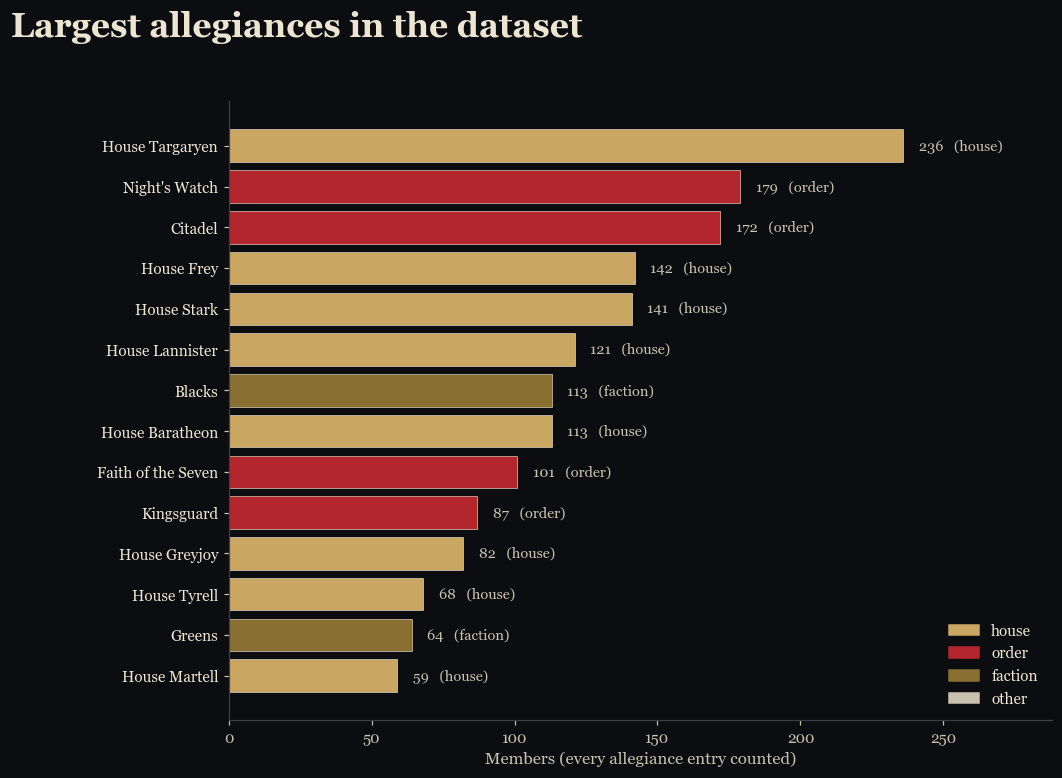

In [82]:
top = multi_counts.most_common(14)


def classify(name):
    if name.startswith('House_'):
        return 'house'
    if name in {"Night's_Watch", "Citadel", "Faith_of_the_Seven", "Kingsguard",
                "Brotherhood_without_banners", "Faceless_Men"}:
        return 'order'
    if name in {"Blacks", "Greens"}:
        return 'faction'
    return 'other'


CATEGORY_COLOR = {
    'house':   PALETTE['gold'],
    'order':   PALETTE['crimson_bright'],
    'faction': PALETTE['gold_deep'],
    'other':   PALETTE['ink_soft'],
}

labels  = [h for h, _ in top][::-1]
counts  = [c for _, c in top][::-1]
classes = [classify(h) for h in labels]
colors  = [CATEGORY_COLOR[c] for c in classes]

fig, ax = plt.subplots(figsize=(11, 7.5))
bars = ax.barh(range(len(labels)), counts, color=colors,
               edgecolor=PALETTE['ink'], linewidth=0.4)

for i, (n, h, cls) in enumerate(zip(counts, labels, classes)):
    ax.text(n + 3, i, f'  {n}   ({cls})',
            va='center', fontsize=9.5,
            color=PALETTE['ink_soft'], family='serif')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels([h.replace('_', ' ') for h in labels],
                   color=PALETTE['ink'], fontsize=10)
ax.set_xlim(0, max(counts) * 1.22)
ax.set_xlabel('Members (every allegiance entry counted)')

handles = [mpatches.Patch(color=col, label=cat)
           for cat, col in CATEGORY_COLOR.items()]
ax.legend(handles=handles, loc='lower right', fontsize=10,
          labelcolor=PALETTE['ink'], facecolor=PALETTE['bg_alt'],
          edgecolor=PALETTE['line'])

fig.subplots_adjust(top=0.86, left=0.22)
got_title(fig,
          'Largest allegiances in the dataset',
          )

save_fig(fig, 'figures/top15_allegiances.png')
plt.show()


#### Important details:

he list is dominated by the great houses of the ASOIAF universe, although some of the largest groups also are orders. 

There are some importan qualitative notes to mention:

**Blacks (and Greens) are Targaryens too.** These two factions are the opposing sides of the *Dance of the Dragons*, a Targaryen civil war — so most of their members are also tagged `House_Targaryen`. The same characters are counted under both their house and their war faction, which is why the factions rank so high. This also explains part of why House Targaryen is the single largest group: it not only spans this internal conflict but also stretches over a far longer in-universe period than any other house (~300 years of canon), so the wiki accumulates many more Targaryen-tagged characters than for shorter-lived houses.


**Orders are strongly trans-house.** The Night's Watch, Kingsguard, the Faith, the Citadel and the rest recruited by oath, not by blood — their members are drawn from many different houses. An order is thus a *cross-cutting* membership: this is interesting to be aware off when lookin at the later graphs.


- House Targaryen (236) is almost double the next house (Stark and Frey at ~141). With Blacks and Greens, mostly Targaryen, layered on top, its footprint is by far the largest, inflated both by the Dance double-counting and by spanning roughly 300 years of canon while most houses are confined to a single era.
- The bars count allegiance entries, not distinct people, so heights overstate unique membership wherever an order or faction overlaps a house. This sligtly infaltes the counts.
- The fall from Targaryen (236) to Martell (59) across these few groups, and the long flat tail after them (next section), is why the rest of the analysis restricts attention to the largest groups.

### Distribution of houses

How many characters do we actually keep if the analysis is restricted to the top-N primary groups? (Each character is assigned its single largest group.)

Top-14 allegiances (houses + orders + factions): 1,518 / 3,690 characters (41.1%)
Remaining (minor houses / unlabelled / out of top-14): 2,172 (58.9%)


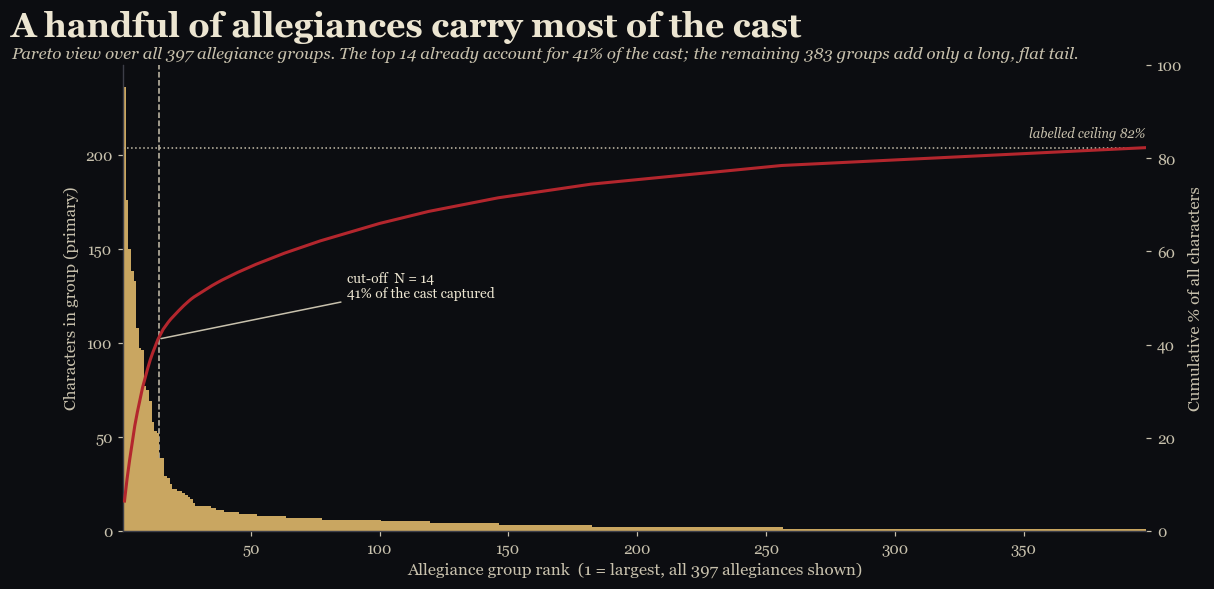

In [ ]:

TOP_N = 14
TOTAL = len(df)

primary_counts = Counter(v for v in primary_house.values() if v)

# (a) Top-N groups of any type.
top_groups = [g for g, _ in primary_counts.most_common(TOP_N)]
covered = sum(primary_counts[g] for g in top_groups)

print(f'Top-{TOP_N} allegiances (houses + orders + factions): '
      f'{covered:,} / {TOTAL:,} characters ({covered/TOTAL:.1%})')

print(f'Remaining (minor houses / unlabelled / out of top-{TOP_N}): '
      f'{TOTAL - covered:,} ({(TOTAL - covered)/TOTAL:.1%})')



ranked = primary_counts.most_common()
n_groups = len(ranked)
sizes = np.array([n for _, n in ranked])
cum_pct = np.cumsum(sizes) / TOTAL * 100
x = np.arange(1, n_groups + 1)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(x, sizes, width=1.0, color=PALETTE['gold'],
       edgecolor=PALETTE['gold'], linewidth=0, zorder=2)
ax.set_xlabel(f'Allegiance group rank  (1 = largest, all {n_groups} allegiances shown)')
ax.set_ylabel('Characters in group (primary)')
ax.set_xlim(0.5, n_groups + 0.5)

ax2 = ax.twinx()
ax2.plot(x, cum_pct, color=PALETTE['crimson_bright'], lw=2, zorder=3)
ax2.set_ylabel('Cumulative % of all characters')
ax2.set_ylim(0, 100)

# Cut-off marker at TOP_N
ax.axvline(TOP_N + 0.5, color=PALETTE['ink_soft'], ls='--', lw=1, zorder=1)
ax2.annotate(f'cut-off  N = {TOP_N}\n{cum_pct[TOP_N - 1]:.0f}% of the cast captured',
             xy=(TOP_N, cum_pct[TOP_N - 1]),
             xytext=(n_groups * 0.22, 50),
             color=PALETTE['ink'], fontsize=9, family='serif',
             arrowprops=dict(arrowstyle='-', color=PALETTE['ink_soft'], lw=1))
ax2.axhline(cum_pct[-1], color=PALETTE['ink_soft'], ls=':', lw=1)
ax2.text(n_groups, cum_pct[-1] + 1.5, f'labelled ceiling {cum_pct[-1]:.0f}%',
         ha='right', va='bottom', fontsize=8.5, style='italic',
         color=PALETTE['ink_soft'], family='serif')

got_title(fig, 'A handful of allegiances carry most of the cast',
          f'Pareto view over all {n_groups} allegiance groups. The top {TOP_N} '
          f'already account for {cum_pct[TOP_N - 1]:.0f}% of the cast; the '
          f'remaining {n_groups - TOP_N} groups add only a long, flat tail.')
save_fig(fig, 'website/figures/graph_analysis/allegiance_pareto_cutoff.png')
plt.show()


### Method note -  Why this cutoff?

A clarification first: the Pareto runs over **397 distinct *primary* groups**, not
the 547 distinct allegiance *labels* counted earlier. The difference is the
collapse step, 547 labels appear *somewhere* on a character's allegiance list,
but once every character is reduced to their single largest group, 150 of those
labels are never anyone's primary and drop out. Everything in this section is
about the 397 primary groups.

We have picked houses that a

The Pareto also shows there is **no sharp elbow**: group size decays smoothly, so
no single N is "the" natural cut. The top 14 capture ~41% of the cast, and the
curve only really flattens toward its ~82% labelled ceiling around rank ~25–35 —
so 14 is *not* the knee of the curve, and we do not claim it is.

Because of this we deliberately use **two different cut-offs** for two different
jobs:

- **N ≈ 14 for the coloured network plots — a legibility cap, not a Pareto
  knee.** A node-link diagram can only carry ~12–15 visually distinguishable
  colours before the ground-truth figure becomes unreadable confetti. 14 is
  chosen for the reader's eye; the Pareto's role here is only to confirm that 14
  still captures the dominant groups (the biggest 14 of 397 already cover ~41%
  of everyone), not that 14 is optimal.
- **A wider set for the quantitative metrics.** Community-vs-allegiance scores
  (ARI, NMI, purity, …) have no colour constraint, so restricting *them* to 14
  would discard signal for no reason. Those are computed over a broader set
  (e.g. the top ~30 primary groups, or all groups above a small minimum size),
  so the analysis is not bottlenecked by a visualisation limit.

**What we gain** from capping the *visualisation* at ~14:

- *Legibility.* The ground-truth plot stays readable; beyond ~15 colours it is
  noise rather than a reference.
- *Statistical stability.* The kept groups are large enough that per-group
  summaries are not dominated by one or two characters; sub-handful groups give
  unstable estimates.
- *Signal concentration.* The discarded tail is overwhelmingly singletons and
  minor houses — the same near-isolated nodes the LCC check showed carry almost
  none of the edges. We drop names, not structure.

**What we still lose**, and must keep in mind when reading the results:

- *Coverage of the coloured view.* Only ~41% of characters are coloured (≈29% if
  restricted to noble `House_*`); the rest are pooled into a grey "other" in the
  figures. (The metrics mitigate this by using the wider set, but the *pictures*
  are still a top-14 view.)
- *Selection bias.* Any statement about *which* houses cluster cleanly is a
  statement about the *largest* groups. Minor houses cannot be evaluated —
  absence of evidence here is not evidence of absence.
- *Interaction with earlier choices.* The ranking is by primary-group size,
  itself shaped by the largest-global primary rule and by temporal smear
  (long-running houses such as Targaryen accumulate more members than
  short-lived ones), so the cut mildly favours old, large dynasties.
- *Algorithm vs. evaluation mismatch.* Louvain runs on the full LCC, so excluded
  nodes still shape the communities — they just enter the scoring only through
  the wider metric set, never the coloured plots.

We judge the trade acceptable: ~14 is a *visualisation* boundary, the metrics use
more groups, and the Pareto shows the excluded tail adds little structural signal
for the legibility it would cost.

## Social Network coloured by largest allegiance:


C3 top-degree pick added: Jaehaerys I Targaryen (deg=182)


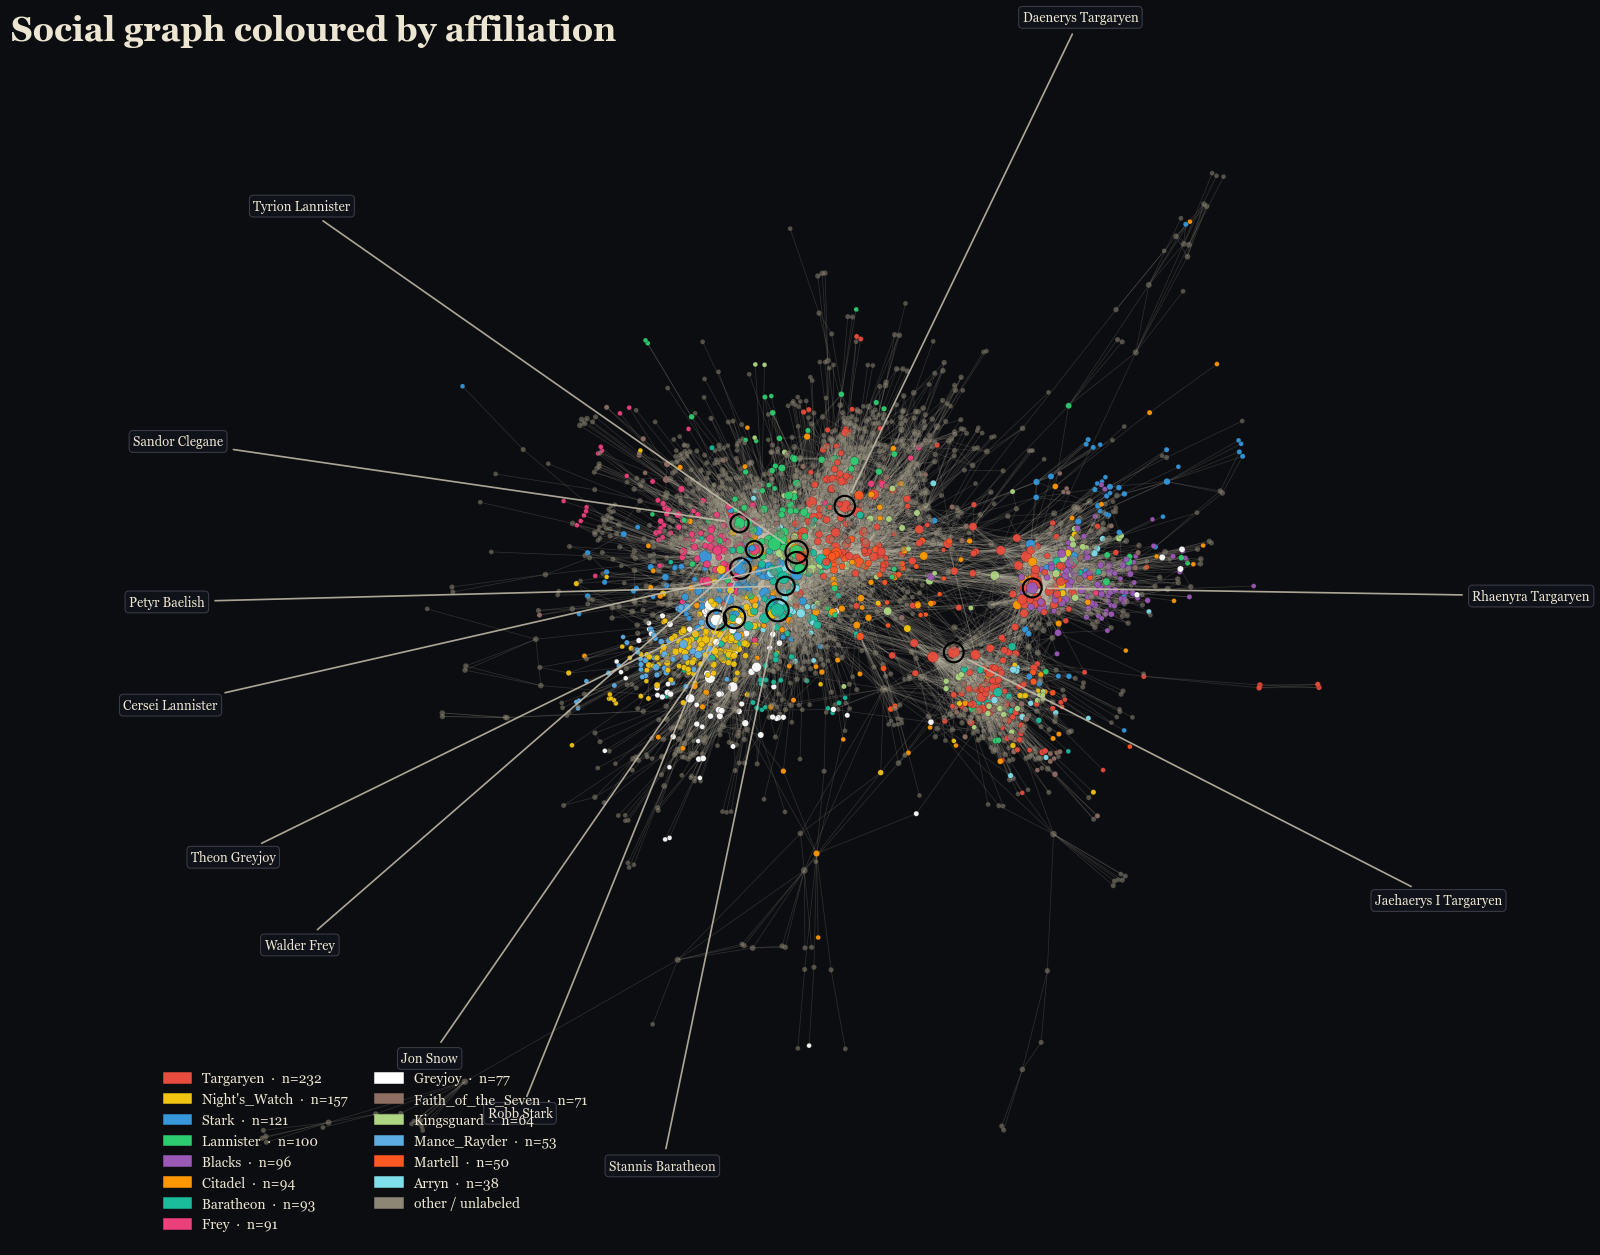

In [70]:
TOP_HOUSES = 14
labelled = [n for n in LCC.nodes() if primary_house.get(n)]
house_counts_primary = Counter(primary_house[n] for n in labelled)
top_houses = [h for h, _ in house_counts_primary.most_common(TOP_HOUSES)]
house_palette = distinctive_colors(TOP_HOUSES)  
house_color = {h: house_palette[i] for i, h in enumerate(top_houses)}
OTHER = PALETTE['muted']

# Spring layout
pos = nx.spring_layout(LCC, seed=42, k=0.18, iterations=120)


def draw_network(node_colors, node_sizes, node_alphas, title, subtitle, save_name,
                 legend_handles=None):
    fig, ax = plt.subplots(figsize=(15, 13))
    nx.draw_networkx_edges(LCC, pos, alpha=0.18,
                           edge_color=PALETTE['ink_soft'],
                           width=0.5, ax=ax)
    ax.scatter([pos[n][0] for n in LCC.nodes()],
               [pos[n][1] for n in LCC.nodes()],
               c=node_colors, s=node_sizes, alpha=node_alphas,
               linewidths=0.15, edgecolors=PALETTE['bg'], zorder=3)

    FEATURED = [
        'Jon_Snow', 'Cersei_Lannister', 'Daenerys_Targaryen',
        'Tyrion_Lannister', 'Petyr_Baelish', 'Theon_Greyjoy',
        'Walder_Frey', 'Stannis_Baratheon', 'Robb_Stark',
        'Sandor_Clegane', 'Rhaenyra_Targaryen',
    ]
    # We wanted to investigate the a charcter from one of the clear louvian groups, so we picked the most connected character from V3 
    TARG_COMM = 3
    c3_members = [n for n in LCC.nodes() if partition[n] == TARG_COMM]
    if c3_members:
        c3_top = max(c3_members, key=lambda n: LCC.degree(n))
        if c3_top not in FEATURED:
            FEATURED.append(c3_top)
            print(f'C{TARG_COMM} top-degree pick added: {c3_top.replace("_", " ")} '
                  f'(deg={LCC.degree(c3_top)})')
    top_deg = [n for n in FEATURED if n in LCC]

    xs = np.array([pos[n][0] for n in LCC.nodes()])
    ys = np.array([pos[n][1] for n in LCC.nodes()])
    cx, cy = xs.mean(), ys.mean()
    ring_r = max(xs.max() - xs.min(), ys.max() - ys.min()) * 0.60

    def angle_of(n):
        x, y = pos[n]
        return np.arctan2(y - cy, x - cx)

    # Sort by angle, then enforce a minimum gap so labels spread evenly
    angles = sorted(((angle_of(n), n) for n in top_deg), key=lambda t: t[0])
    min_gap = 2 * np.pi / 14   # ~25.7\u00b0 between any two labels
    adjusted = []
    prev_a = angles[0][0] - min_gap
    for a, n in angles:
        if a < prev_a + min_gap:
            a = prev_a + min_gap
        adjusted.append((a, n))
        prev_a = a

    # Per-character angular nudge (radians). Negative = south, positive = north
    # for labels on the east side of the layout; mirrored on the west side.
    NAME_NUDGE = {
        'Daenerys_Targaryen': -0.22,   # a bit south
        'Arya_Stark':         +0.22,   # a bit north
    }
    adjusted = [(a + NAME_NUDGE.get(n, 0.0), n) for a, n in adjusted]

    # Black ring around each featured character so the eye finds them fast.
    ring_xs = [pos[n][0] for n in top_deg]
    ring_ys = [pos[n][1] for n in top_deg]
    ring_sizes = [(6 + (LCC.degree(n) ** 0.5) * 4) * 2.8 for n in top_deg]
    ax.scatter(ring_xs, ring_ys, s=ring_sizes,
               facecolors='none', edgecolors='black',
               linewidths=1.4, zorder=4)

    label_bbox = dict(boxstyle='round,pad=0.3',
                      fc=PALETTE['bg_alt'], ec=PALETTE['line_strong'],
                      lw=0.7, alpha=0.95)
    arrow_props = dict(arrowstyle='-',
                       color=PALETTE['ink_soft'],
                       lw=1.1, alpha=0.85,
                       shrinkA=4, shrinkB=10)
    for a, n in adjusted:
        lx = cx + ring_r * np.cos(a)
        ly = cy + ring_r * np.sin(a)
        ha = 'left' if np.cos(a) >= 0 else 'right'
        ax.annotate(name_by_id.get(n, n),
                    xy=pos[n], xytext=(lx, ly),
                    ha=ha, va='center',
                    fontsize=8.5, color=PALETTE['ink'],
                    family='serif', bbox=label_bbox,
                    arrowprops=arrow_props, zorder=5)
    if legend_handles:
        ax.legend(handles=legend_handles, loc='lower left', fontsize=9, ncol=2,
                  labelcolor=PALETTE['ink'],
                  facecolor=PALETTE['bg_alt'], edgecolor=PALETTE['line'])
    ax.axis('off')
    fig.subplots_adjust(top=0.93)
    got_title(fig, title, subtitle)
    save_fig(fig, save_name)
    plt.show()


# House view 
node_colors = [house_color.get(primary_house.get(n, ''), OTHER) for n in LCC.nodes()]
# Size scales with degree (number of connections). sqrt keeps hubs visible without
# letting them blow out the rest of the picture.
deg = dict(LCC.degree())
node_sizes  = [6 + (deg[n] ** 0.5) * 4 for n in LCC.nodes()]
node_alphas = [0.95 if primary_house.get(n) in house_color else 0.55 for n in LCC.nodes()]

legend = [mpatches.Patch(color=house_color[h],
                         label=f"{h.replace('House_', '')}  ·  n={house_counts_primary[h]}")
          for h in top_houses]
legend.append(mpatches.Patch(color=OTHER, label='other / unlabeled'))

draw_network(node_colors, node_sizes, node_alphas,
             'Social graph coloured by affiliation',
             '',
             'website/figures/graph_analysis/social_affiliation_graph.png',
             legend_handles=legend)


From this graph we already see three very significant hubs.

From further analysis, we see that these three groups correspond to three distinct series in the story.

The largest group correspond to the main game of thrones series (A Song of Ice and Fire)
The Second largest group is from the A Dance of Dragons Prequel (The one with the Blacks Faction) which are a prequel about a civil war

The third book corresponds to the Fire And Blood novella, which tells the story about a the early days of the universe. 

Looking at the graph, there seems to be cosine-like relationships of houses, where the central characters (the highlighted) are centered in the middle having their houses span out in approximately lines.



## Louvian Groups

C3 top-degree pick added: Jaehaerys I Targaryen (deg=182)


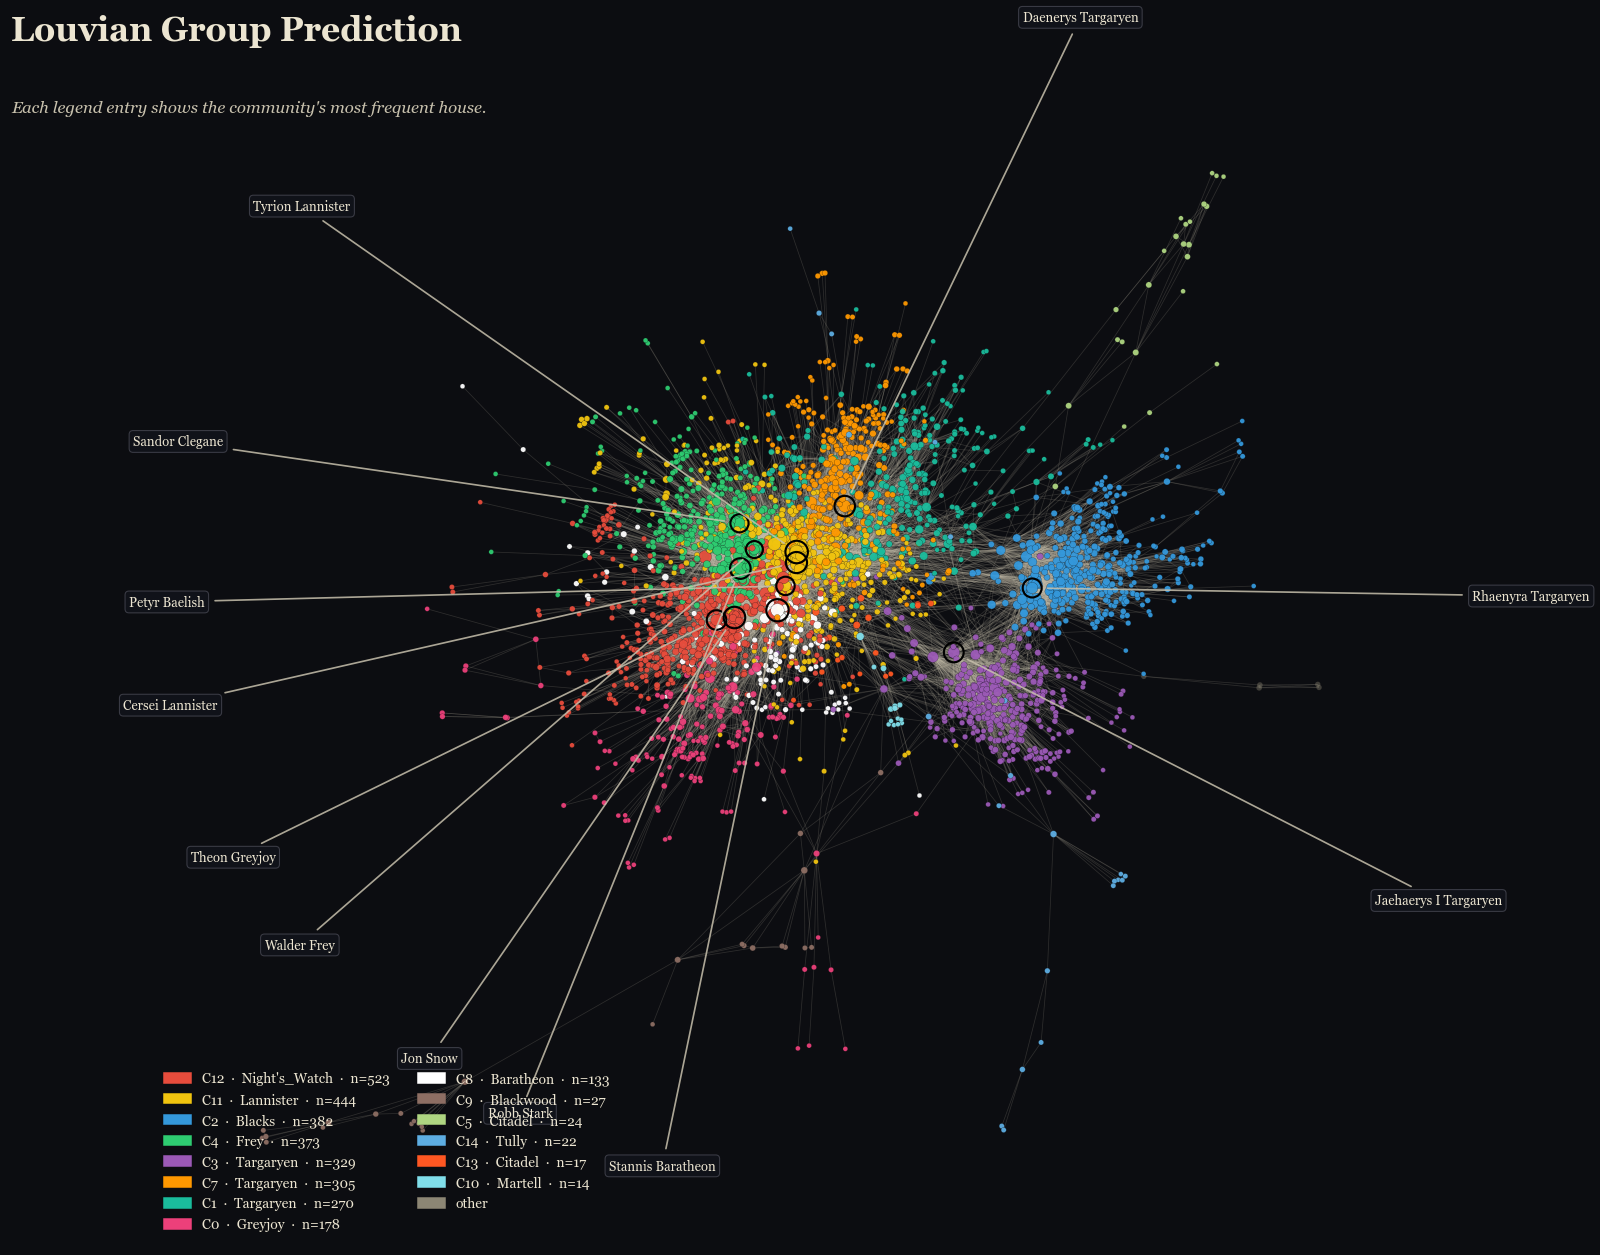

In [71]:
TOP_C = 14  # match the 14-colour distinctive palette so no two communities share a colour
top_comms = [c for c, _ in community_sizes.most_common(TOP_C)]
comm_palette = distinctive_colors(TOP_C)
comm_color = {c: comm_palette[i] for i, c in enumerate(top_comms)}

dom_house_per_comm = {}
for c in top_comms:
    members = [n for n in LCC.nodes() if partition[n] == c and
primary_house.get(n)]
    if members:
        houses_here = Counter(primary_house[n] for n in members)
        dom_house_per_comm[c] = houses_here.most_common(1)[0][0]
    else:
        dom_house_per_comm[c] = '?'

node_colors = [comm_color.get(partition[n], OTHER) for n in LCC.nodes()]
# Same degree-scaled sizing as Step 1, so the comparison stays fair.
node_sizes  = [6 + (LCC.degree(n) ** 0.5) * 4 for n in LCC.nodes()]
node_alphas = [0.95 if partition[n] in comm_color else 0.4 for n in LCC.nodes()]

legend = [mpatches.Patch(color=comm_color[c],
                        label=f"C{c}  ·  {dom_house_per_comm[c].replace('House_',
'')}  ·  n={community_sizes[c]}")
        for c in top_comms]
legend.append(mpatches.Patch(color=OTHER, label='other'))

draw_network(node_colors, node_sizes, node_alphas,
            'Louvian Group Prediction',
            'Each legend entry shows the community\'s most frequent house.',
            'website/figures/graph_analysis/louvian_plot.png',
            legend_handles=legend)

## Do allegiances predict communities?

In [72]:
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
)

# Ground truth = the largest-global primary allegiance from section 1.
labelled = [n for n in LCC.nodes() if primary_house.get(n)]
coverage = len(labelled) / LCC.number_of_nodes()

y_true = [primary_house[n] for n in labelled]
y_comm = [partition[n] for n in labelled]

# Dominant-allegiance vote per community (labelled members only).
by_comm = defaultdict(Counter)
for n in labelled:
    by_comm[partition[n]][primary_house[n]] += 1
dominant = {c: cnt.most_common(1)[0][0] for c, cnt in by_comm.items()}

accuracy = sum(dominant.get(partition[n]) == primary_house[n]
                for n in labelled) / len(labelled)
ari  = adjusted_rand_score(y_true, y_comm)
nmi  = normalized_mutual_info_score(y_true, y_comm)
homo, comp, _ = homogeneity_completeness_v_measure(y_true, y_comm)

# Shuffled-community null: break the node -> community link, keep the marginals.
rng = random.Random(0)
y_shuf = y_comm[:]
rng.shuffle(y_shuf)

shuf_by_comm = defaultdict(Counter)
for lab, c in zip(y_true, y_shuf):
    shuf_by_comm[c][lab] += 1
shuf_dom = {c: cnt.most_common(1)[0][0] for c, cnt in shuf_by_comm.items()}

shuf_acc = sum(shuf_dom.get(c) == lab
                for lab, c in zip(y_true, y_shuf)) / len(y_true)
shuf_ari = adjusted_rand_score(y_true, y_shuf)
shuf_nmi = normalized_mutual_info_score(y_true, y_shuf)
shuf_homo, shuf_comp, _ = homogeneity_completeness_v_measure(y_true, y_shuf)

scores = pd.DataFrame(
    {'Louvain':  [accuracy, ari, nmi, homo, comp],
    'Shuffled': [shuf_acc, shuf_ari, shuf_nmi, shuf_homo, shuf_comp]},
    index=['accuracy', 'ARI', 'NMI', 'homogeneity', 'completeness'],
).round(3)

print(f'Scored on {len(labelled):,} / {LCC.number_of_nodes():,} LCC characters '
    f'with a primary allegiance ({coverage:.1%} coverage).')
print(f'Distinct allegiances: {len(set(y_true)):,}   '
    f'Louvain communities: {len(set(y_comm)):,}\n')
print(scores.to_string())

Scored on 2,643 / 3,046 LCC characters with a primary allegiance (86.8% coverage).
Distinct allegiances: 364   Louvain communities: 15

              Louvain  Shuffled
accuracy        0.240     0.090
ARI             0.103    -0.000
NMI             0.388     0.144
homogeneity     0.287     0.107
completeness    0.598     0.222


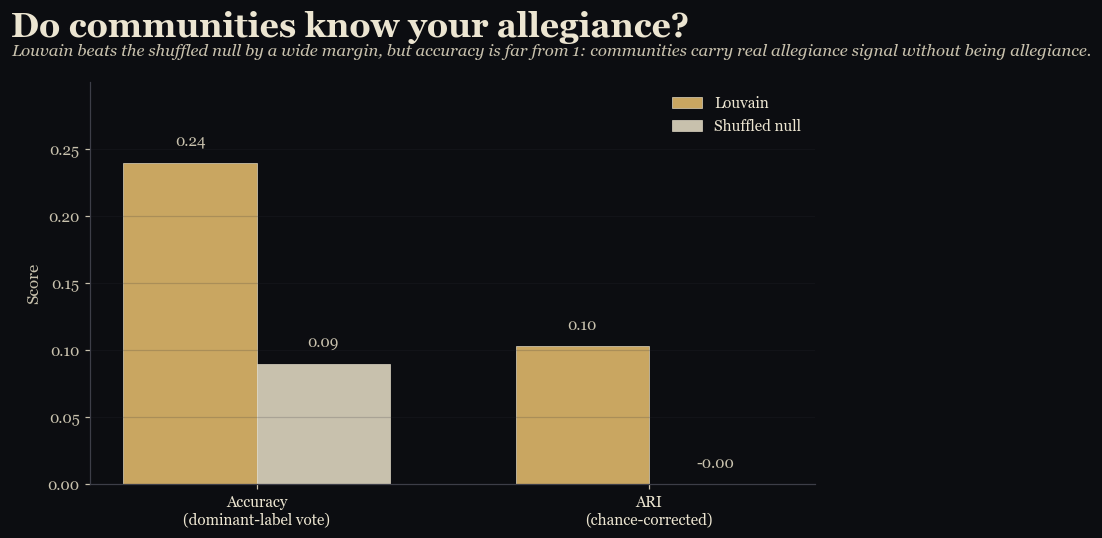

In [73]:
fig, ax = plt.subplots(figsize=(8.5, 5))

metrics = ['accuracy', 'ARI']
louv = [accuracy, ari]
null = [shuf_acc, shuf_ari]
x = np.arange(len(metrics))
w = 0.34

b1 = ax.bar(x - w / 2, louv, w, label='Louvain',
            color=PALETTE['gold'], edgecolor=PALETTE['ink'], linewidth=0.4)
b2 = ax.bar(x + w / 2, null, w, label='Shuffled null',
            color=PALETTE['ink_soft'], edgecolor=PALETTE['ink'], linewidth=0.4)

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f'{b.get_height():.2f}', ha='center', fontsize=10,
                color=PALETTE['ink_soft'], family='serif')

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy\n(dominant-label vote)', 'ARI\n(chance-corrected)'],
                    color=PALETTE['ink'])
ax.set_ylabel('Score')
ax.set_ylim(0, max(louv) * 1.25)
ax.legend(loc='upper right', fontsize=10, labelcolor=PALETTE['ink'],
        facecolor=PALETTE['bg_alt'], edgecolor=PALETTE['line'])
ax.grid(alpha=0.2, axis='y', color=PALETTE['line'])

fig.subplots_adjust(top=0.84)
got_title(fig,
        'Do communities know your allegiance?',
        'Louvain beats the shuffled null by a wide margin, but accuracy is far from 1: communities carry real allegiance signal without being allegiance.')
save_fig(fig, 'website/figures/graph_analysis/allegiance_prediction_vs_null.png')
plt.show()


**What the chart states.** Each Louvain community casts a single vote, its most common allegiance, and every member is predicted to hold it. Louvain reaches 24% accuracy against a 9% shuffled-label
  null, and a chance-corrected ARI of 0.10 against a null of essentially 0. The community structure is therefore genuinely tracking allegiance, but it is a faint signal: knowing a character's community
  leaves you wrong about their allegiance roughly three times in four.

  **Why this method is suitable.** Raw accuracy alone is misleading here, because with 15 communities and 364 allegiances a vote can look good by sheer label imbalance. So we pair it with two safeguards.
  ARI is corrected for chance, so neither the number of communities nor the size of the label space can inflate it. The shuffled-label null is an empirical floor: it keeps the community sizes and
  allegiance frequencies fixed and only breaks the link between them, so any gap above it is real association and not an artefact of the marginals. Reading the two bars together, the honest verdict is
  "well above chance, far below identity."

  What completeness vs homogeneity say and do

  They are a complementary pair scoring the same clustering from the two directions a "community = allegiance" claim could fail:

| Metric | Question it asks | Penalises | Your value |
  |---|---|---|---|
  | **Homogeneity** | Is each community made of a single allegiance? | Communities that mix many allegiances | 0.287 |
  | **Completeness** | Are all members of an allegiance kept in one community? | An allegiance scattered across many communities | 0.598 |

  (NMI and V-measure are just the two combined; that is why NMI 0.388 sits between them.)

  What the asymmetry tells you here. Completeness (0.60) is roughly double homogeneity (0.29). That specific direction is the finding:

  - High-ish completeness: a given allegiance's members do tend to land together in one community. Houses are not shredded across the partition.
  - Low homogeneity: but the community they land in is a melting pot, dominated by other and larger groups. A community is not "a house," it is "a house plus everything the network glued around it."

  This is the textbook signature of under-clustering: 15 communities cannot resolve 364 allegiances, so Louvain keeps each allegiance intact but packs many of them into the same big community (the Night's
   Watch / Wall-region absorption pattern you saw earlier). It also explains why the dominant-label vote only hits 24%: the vote inside a mixed community goes to whichever large group sits there, not to
  the smaller allegiances sharing it. If you split those big communities (higher Louvain resolution, or Leiden), homogeneity would rise and completeness would fall, moving them toward each other.

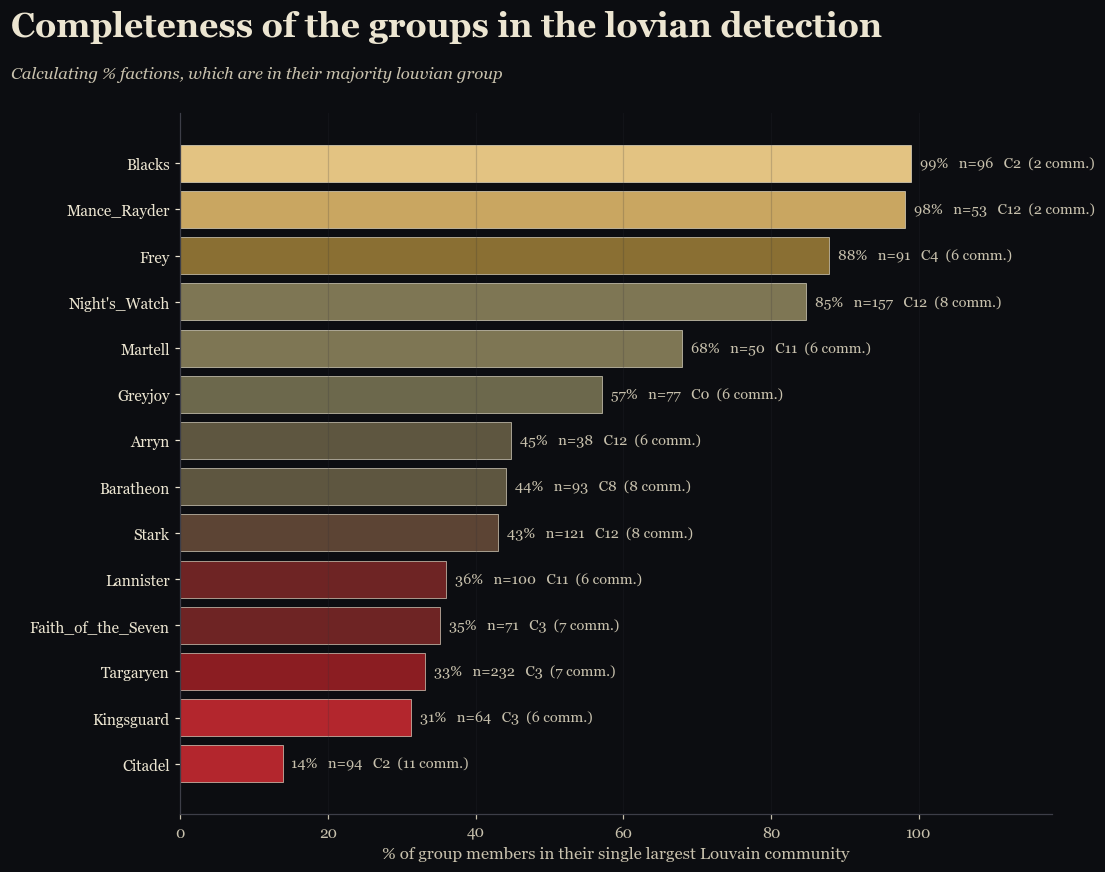

In [74]:
TOP_GROUPS = 14  # same grouping as the Step 1 "social graph coloured by allegiance" plot

# Top primary allegiance groups over LCC characters. No House_* filter, so
# orders/factions are included -- exactly the set the Step 1 plot colours.
labelled = [n for n in LCC.nodes() if primary_house.get(n)]
group_members = Counter(primary_house[n] for n in labelled)
top_houses = [h for h, _ in group_members.most_common(TOP_GROUPS)]

rows = []
for h in top_houses:
    members = [n for n in LCC.nodes() if primary_house.get(n) == h]
    comm_dist = Counter(partition[n] for n in members)
    dom_comm, dom_count = comm_dist.most_common(1)[0]
    rows.append({
        'house': h.replace('House_', ''),
        'members': len(members),
        'dominant_community': dom_comm,
        'in_dominant_pct': dom_count / len(members) * 100,
        'n_communities': len(comm_dist),
    })

purity_df = (
    pd.DataFrame(rows)
    .sort_values('in_dominant_pct', ascending=True)
    .reset_index(drop=True)
)

# Crimson (scattered) -> gold (cohesive), ordered by the sorted purity.
bar_colors = diverging_colors(len(purity_df))

fig, ax = plt.subplots(figsize=(11, 0.45 * len(purity_df) + 2.2))
bars = ax.barh(
    purity_df['house'],
    purity_df['in_dominant_pct'],
    color=bar_colors,
    edgecolor=PALETTE['ink'],
    linewidth=0.4,
)

for bar, row in zip(bars, purity_df.itertuples()):
    ax.text(
        bar.get_width() + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f'{row.in_dominant_pct:.0f}%   n={row.members}   '
        f'C{row.dominant_community}  ({row.n_communities} comm.)',
        va='center',
        fontsize=9.5,
        color=PALETTE['ink_soft'],
        family='serif',
    )

ax.set_xlim(0, 118)
ax.set_xlabel('% of group members in their single largest Louvain community')
ax.tick_params(axis='y', colors=PALETTE['ink'])
ax.grid(alpha=0.2, axis='x', color=PALETTE['line'])

fig.subplots_adjust(top=0.86, left=0.18)
got_title(
    fig,
    'Completeness of the groups in the lovian detection',
    f'Calculating % factions, which are in their majority louvian group',
)
save_fig(fig, 'website/figures/graph_analysis/group_modal_community_completeness.png')
plt.show()


From this graph, we get an overview of how tight-knit the communities are.

The most tight knit house is the blacks, whom all stem from the same book- A Dance of Dragons, giving it an extremely tight group.

The next 4- most close-knit groups are all very geographically dependent - and isolated in the storyline, with the knights watch and Mance_Rayder (wildlings) storylines being isolated to the north, and house Frey being centered around one bridgecrossing.

The main houses in the storyline Stark, Lannister and targaryan and baratheon all have smaller completeness percentages. This might be due to main characters stories having large, noisy networks as they meet more characters.

Lastly it's interesteing to note that the citadel only as 14%. From the story, this makes extremely good sense, as they work as the 'Wise men' for all houses around the universe, being extremely spread out.


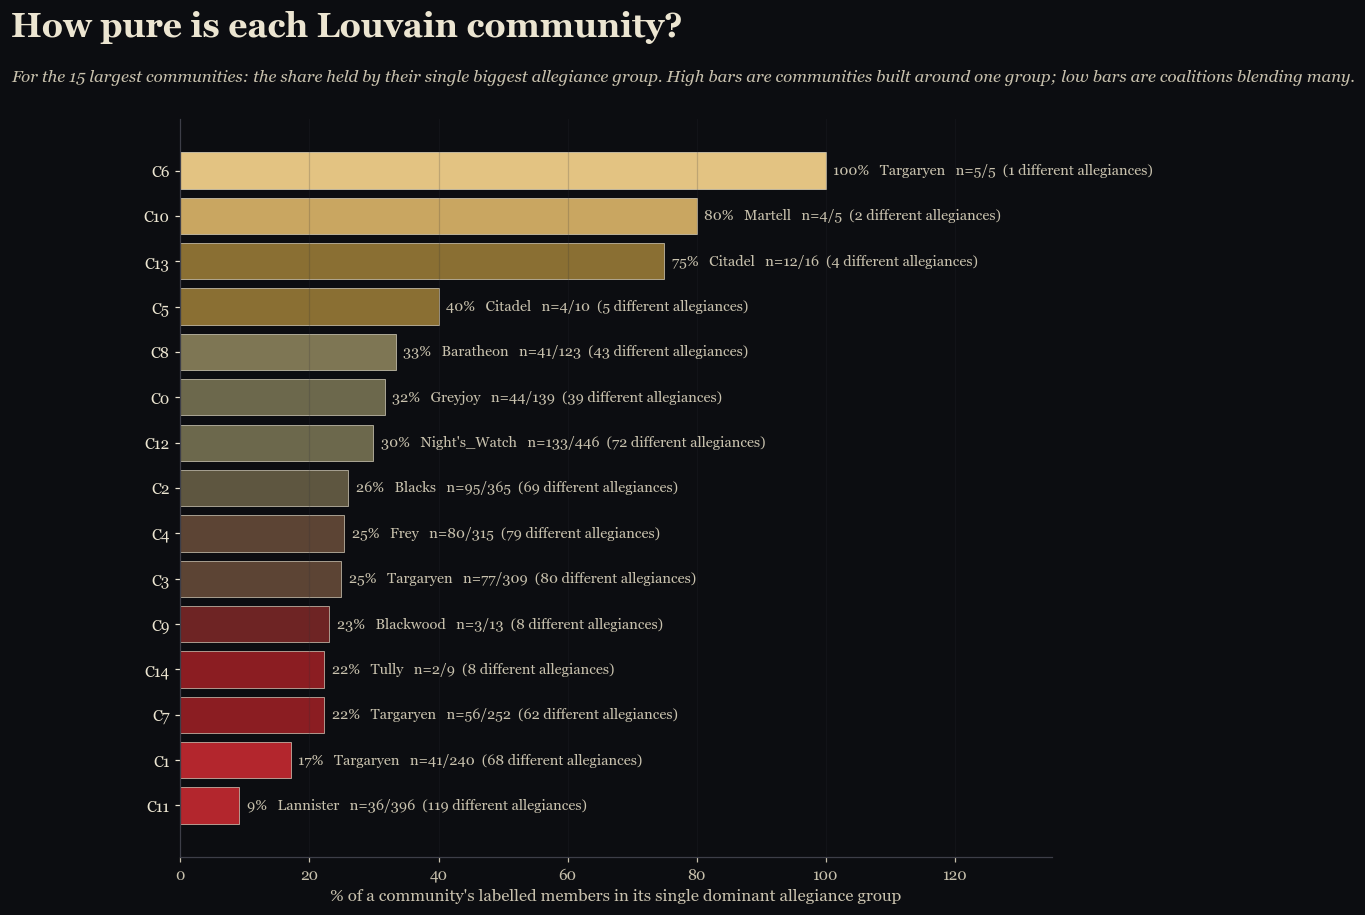

In [75]:
TOP_C = 15  # largest Louvain communities (matches the Step 2 plot)
top_comms = [c for c, _ in community_sizes.most_common(TOP_C)]

rows = []
for c in top_comms:
    members = [n for n in LCC.nodes() if partition[n] == c]
    grp = [primary_house[n] for n in members if primary_house.get(n)]
    if not grp:
        continue
    grp_dist = Counter(grp)
    dom_grp, dom_count = grp_dist.most_common(1)[0]
    rows.append({
        'community': f'C{c}',
        'size': len(members),
        'labelled': len(grp),
        'dominant_group': dom_grp.replace('House_', ''),
        'dom_count': dom_count,                       # members in the largest group
        'dom_pct': dom_count / len(grp) * 100,
        'n_groups': len(grp_dist),
    })

homog_df = (
    pd.DataFrame(rows)
    .sort_values('dom_pct', ascending=True)
    .reset_index(drop=True)
)

# Crimson (mixed coalition) -> gold (one group dominates).
bar_colors = diverging_colors(len(homog_df))

fig, ax = plt.subplots(figsize=(11, 0.45 * len(homog_df) + 2.2))
bars = ax.barh(
    homog_df['community'],
    homog_df['dom_pct'],
    color=bar_colors,
    edgecolor=PALETTE['ink'],
    linewidth=0.4,
)

for bar, row in zip(bars, homog_df.itertuples()):
    ax.text(
        bar.get_width() + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f'{row.dom_pct:.0f}%   {row.dominant_group}   '
        f'n={row.dom_count}/{row.labelled}  ({row.n_groups} different allegiances)',
        va='center',
        fontsize=9.5,
        color=PALETTE['ink_soft'],
        family='serif',
    )

ax.set_xlim(0, 135)
ax.set_xlabel("% of a community's labelled members in its single dominant allegiance group")
ax.tick_params(axis='y', colors=PALETTE['ink'])
ax.grid(alpha=0.2, axis='x', color=PALETTE['line'])

fig.subplots_adjust(top=0.86, left=0.18)
got_title(
    fig,
    'How pure is each Louvain community?',
    f'For the {len(homog_df)} largest communities: the share held by their single '
    'biggest allegiance group. High bars are communities built around one group; '
    'low bars are coalitions blending many.',
)
save_fig(fig, 'website/figures/graph_analysis/community_purity_homogeneity.png')
plt.show()


# SIde stuff

### Exploratory check — is the C3 Targaryen lobe the *Dance of the Dragons*?

The Step 2 plot showed an outer Targaryen lobe that fragments off by era. Our
hypothesis is that this is the **Dance of the Dragons** (the 129–131 AC Targaryen
civil war, *Fire & Blood*), not the later **Dunk & Egg** era (*A Knight of the
Seven Kingdoms*, ~209 AC). The wiki tags Dance combatants with explicit
`Blacks` / `Greens` faction labels, so we can test this directly: colour every
Blacks/Greens character, find which Louvain community they concentrate in, and
read off that community's roster to see *which* Targaryen era it actually is.

Blacks-tagged in LCC :  112
Greens-tagged in LCC :   63
Dance-tagged total   :  160
They concentrate in community C2 (159/160 = 99% of all faction-tagged)
C2 size: 382 members; 42% carry a Blacks/Greens tag

Dance-era anchors found in C2     : 9/9  ['Rhaenyra Targaryen', 'Aegon II Targaryen', 'Daemon Targaryen', 'Alicent Hightower', 'Aemond Targaryen', 'Corlys Velaryon', 'Otto Hightower', 'Viserys I Targaryen', 'Aegon III Targaryen']
Dunk & Egg anchors found in C2    : 0/8  []

Top 25 of C2 by degree (B=Blacks, G=Greens, .=untagged):
  deg 150  [  B]  Rhaenyra Targaryen
  deg 143  [  .]  Aegon III Targaryen
  deg 127  [  .]  Aegon II Targaryen
  deg  82  [  .]  Viserys I Targaryen
  deg  80  [  B]  Daemon Targaryen
  deg  76  [B+G]  Corlys Velaryon
  deg  75  [  .]  Mushroom
  deg  73  [  G]  Unwin Peake
  deg  71  [  B]  Alyn Velaryon
  deg  69  [  B]  Cregan Stark
  deg  65  [  .]  Viserys II Targaryen
  deg  63  [  G]  Criston Cole
  deg  57  [  G]  Alicent Hightower
  deg  56  [  B

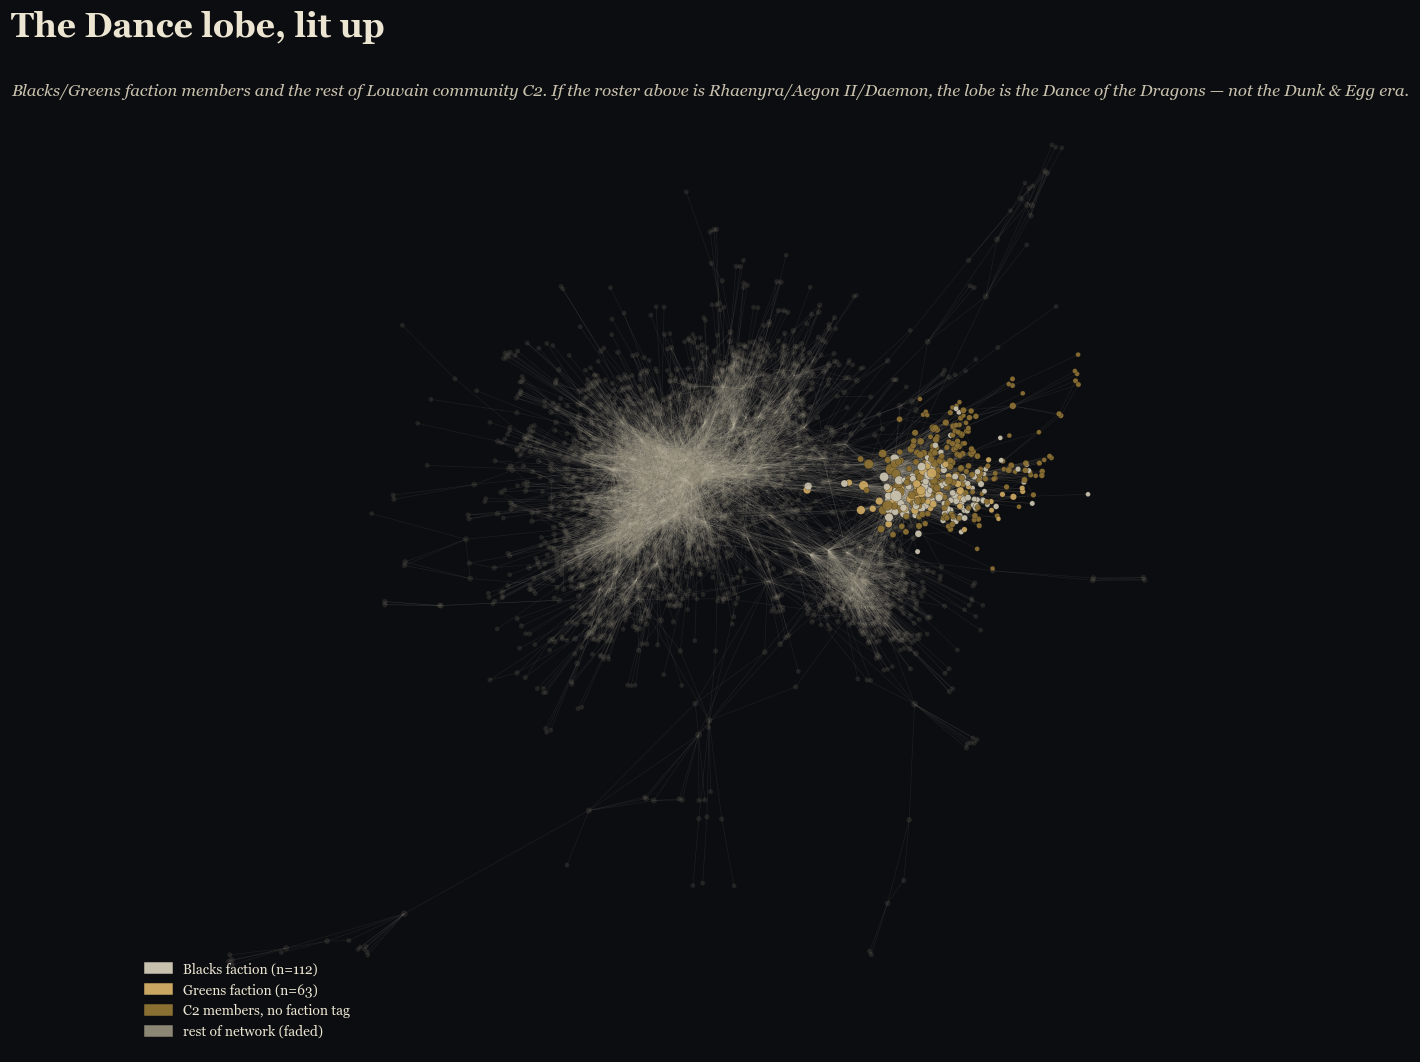

In [76]:
# --- Which Louvain community do the Dance factions concentrate in? ----------
blacks = {r['ID'] for _, r in df.iterrows()
          if 'Blacks' in (r['allegiance'].split(';') if r['allegiance'] else [])}
greens = {r['ID'] for _, r in df.iterrows()
          if 'Greens' in (r['allegiance'].split(';') if r['allegiance'] else [])}
dance = (blacks | greens) & set(LCC.nodes())

comm_of_dance = Counter(partition[n] for n in dance)
C_DANCE, c_dance_n = comm_of_dance.most_common(1)[0]
members = [n for n in LCC.nodes() if partition[n] == C_DANCE]

print(f'Blacks-tagged in LCC : {len(blacks & set(LCC)):>4}')
print(f'Greens-tagged in LCC : {len(greens & set(LCC)):>4}')
print(f'Dance-tagged total   : {len(dance):>4}')
print(f'They concentrate in community C{C_DANCE} '
      f'({c_dance_n}/{len(dance)} = {c_dance_n/len(dance):.0%} of all faction-tagged)')
print(f'C{C_DANCE} size: {len(members)} members; '
      f'{sum(1 for n in members if n in dance)/len(members):.0%} carry a Blacks/Greens tag')

# --- Era anchors: Dance vs. Dunk & Egg -------------------------------------
DANCE_ANCHORS = ['Rhaenyra_Targaryen', 'Aegon_II_Targaryen', 'Daemon_Targaryen',
                 'Alicent_Hightower', 'Aemond_Targaryen', 'Corlys_Velaryon',
                 'Otto_Hightower', 'Viserys_I_Targaryen', 'Aegon_III_Targaryen']
DUNKEGG_ANCHORS = ['Duncan_the_Tall', 'Aegon_V_Targaryen', 'Maekar_I_Targaryen',
                   'Daeron_II_Targaryen', 'Brynden_Rivers', 'Baelor_Targaryen',
                   'Bittersteel', 'Daemon_I_Blackfyre']

def in_cdance(ids):
    return [i for i in ids if i in LCC and partition.get(i) == C_DANCE]

d_hit, e_hit = in_cdance(DANCE_ANCHORS), in_cdance(DUNKEGG_ANCHORS)
print(f'\nDance-era anchors found in C{C_DANCE}     : '
      f'{len(d_hit)}/{len(DANCE_ANCHORS)}  {[name_by_id.get(i,i) for i in d_hit]}')
print(f'Dunk & Egg anchors found in C{C_DANCE}    : '
      f'{len(e_hit)}/{len(DUNKEGG_ANCHORS)}  {[name_by_id.get(i,i) for i in e_hit]}')

print(f'\nTop 25 of C{C_DANCE} by degree (B=Blacks, G=Greens, .=untagged):')
for n in sorted(members, key=lambda x: -LCC.degree(x))[:25]:
    tag = 'B' if (n in blacks and n not in greens) else \
          'G' if (n in greens and n not in blacks) else \
          'B+G' if n in dance else '.'
    print(f'  deg {LCC.degree(n):>3}  [{tag:>3}]  {name_by_id.get(n, n).replace("_"," ")}')

# --- Network coloured by faction / C_DANCE membership ----------------------
C_BLACK = PALETTE['ink_soft']
C_GREEN = PALETTE['gold']
C_REST  = PALETTE['gold_deep']      # C_DANCE members without a faction tag
C_OTHER = PALETTE['muted']

def node_cat(n):
    if n in blacks and n not in greens: return C_BLACK
    if n in greens and n not in blacks: return C_GREEN
    if n in dance:                      return C_BLACK   # B+G seam -> show as Blacks
    if partition[n] == C_DANCE:         return C_REST
    return C_OTHER

node_colors = [node_cat(n) for n in LCC.nodes()]
node_sizes  = [6 + (LCC.degree(n) ** 0.5) * 4 for n in LCC.nodes()]
node_alphas = [0.95 if (n in dance or partition[n] == C_DANCE) else 0.18
               for n in LCC.nodes()]

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(LCC, pos, alpha=0.10,
                       edge_color=PALETTE['ink_soft'], width=0.4, ax=ax)
ax.scatter([pos[n][0] for n in LCC.nodes()],
           [pos[n][1] for n in LCC.nodes()],
           c=node_colors, s=node_sizes, alpha=node_alphas,
           linewidths=0.15, edgecolors=PALETTE['bg'], zorder=3)
ax.axis('off')

legend = [
    mpatches.Patch(color=C_BLACK, label=f'Blacks faction (n={len(blacks & set(LCC))})'),
    mpatches.Patch(color=C_GREEN, label=f'Greens faction (n={len(greens & set(LCC))})'),
    mpatches.Patch(color=C_REST,  label=f'C{C_DANCE} members, no faction tag'),
    mpatches.Patch(color=C_OTHER, label='rest of network (faded)'),
]
ax.legend(handles=legend, loc='lower left', fontsize=9,
          labelcolor=PALETTE['ink'], facecolor=PALETTE['bg_alt'],
          edgecolor=PALETTE['line'])
fig.subplots_adjust(top=0.93)
got_title(fig, 'The Dance lobe, lit up',
          f'Blacks/Greens faction members and the rest of Louvain community '
          f'C{C_DANCE}. If the roster above is Rhaenyra/Aegon II/Daemon, the lobe '
          f'is the Dance of the Dragons — not the Dunk & Egg era.')
save_fig(fig, 'website/figures/graph_analysis/dance_lobe.png')
plt.show()


In [77]:
# --- Explore community C3 specifically: who is in it, and which era/book? ---
C3 = 3   # the "C3" community as labelled in the Step 2 Louvain legend
c3 = [n for n in LCC.nodes() if partition[n] == C3]
print(f'C{C3}: {len(c3)} members'
      f'  ({len(c3)/LCC.number_of_nodes():.1%} of the LCC)\n')

# Dominant primary houses inside C3
house_mix = Counter(primary_house[n] for n in c3 if primary_house.get(n))
print('Top primary houses in C3:')
for h, k in house_mix.most_common(8):
    print(f'  {h.replace("House_"," ").replace("_"," "):<26} {k:>3}  ({k/len(c3):.0%})')

# How many C3 members carry a Dance faction tag?
in_dance = sum(1 for n in c3 if n in blacks or n in greens)
print(f'\nC3 members carrying a Blacks/Greens tag: {in_dance}/{len(c3)} '
      f'({in_dance/len(c3):.0%})')

# Era anchors restricted to C3 — which canon period is this?
ERAS = {
    'Dance of the Dragons (129-131 AC, Fire & Blood)':
        ['Rhaenyra_Targaryen','Aegon_II_Targaryen','Daemon_Targaryen',
         'Alicent_Hightower','Aemond_Targaryen','Corlys_Velaryon',
         'Otto_Hightower','Viserys_I_Targaryen','Aegon_III_Targaryen'],
    'Dunk & Egg (~209 AC, A Knight of the Seven Kingdoms)':
        ['Duncan_the_Tall','Aegon_V_Targaryen','Maekar_I_Targaryen',
         'Daeron_II_Targaryen','Brynden_Rivers','Baelor_Targaryen',
         'Bittersteel','Daemon_I_Blackfyre'],
    'Main saga (297+ AC, A Song of Ice and Fire)':
        ['Daenerys_Targaryen','Jon_Snow','Tyrion_Lannister',
         'Eddard_Stark','Robert_I_Baratheon','Cersei_Lannister'],
}
c3set = set(c3)
print('\nEra-anchor presence inside C3:')
for era, ids in ERAS.items():
    hit = [name_by_id.get(i, i).replace('_',' ') for i in ids if i in c3set]
    print(f'  {len(hit)}/{len(ids)}  {era}')
    if hit:
        print(f'        -> {hit}')

print(f'\nFull C3 roster, top 40 by degree (B/G = Dance faction tag):')
for n in sorted(c3, key=lambda x: -LCC.degree(x))[:40]:
    tag = 'B' if (n in blacks and n not in greens) else \
          'G' if (n in greens and n not in blacks) else \
          'B+G' if (n in blacks and n in greens) else '.'
    ph = primary_house.get(n, '').replace('House_', '')
    print(f'  deg {LCC.degree(n):>3}  [{tag:>3}]  '
          f'{name_by_id.get(n, n).replace("_"," "):<28}  {ph}')

C3: 329 members  (10.8% of the LCC)

Top primary houses in C3:
   Targaryen                  77  (23%)
  Faith of the Seven          25  (8%)
  Kingsguard                  20  (6%)
   Baratheon                  10  (3%)
  Night's Watch               10  (3%)
   Arryn                       9  (3%)
   Velaryon                    8  (2%)
  Citadel                      8  (2%)

C3 members carrying a Blacks/Greens tag: 1/329 (0%)

Era-anchor presence inside C3:
  0/9  Dance of the Dragons (129-131 AC, Fire & Blood)
  0/8  Dunk & Egg (~209 AC, A Knight of the Seven Kingdoms)
  0/6  Main saga (297+ AC, A Song of Ice and Fire)

Full C3 roster, top 40 by degree (B/G = Dance faction tag):
  deg 182  [  .]  Jaehaerys I Targaryen         Targaryen
  deg 127  [  .]  Alysanne Targaryen            Targaryen
  deg 126  [  .]  Maegor I Targaryen            Targaryen
  deg  93  [  .]  Aegon I Targaryen             Targaryen
  deg  62  [  .]  Rhaena Targaryen              Targaryen
  deg  59  [  .]  Alys

### Verdict — C3 is the *Conquest era*, not the Dance

C3 is **not** the Dance of the Dragons and **not** Dunk & Egg (0/8 anchors, no
faction tags, Duncan the Tall absent). It is the **founding Targaryen dynasty**:
Aegon I the Conqueror, Visenya, Rhaenys, Aenys I, Maegor I, and Jaehaerys I &
Alysanne with their court (Septon Barth, Orys & Rogar Baratheon, Harren Hoare) —
roughly **1–100 AC**, the *Fire & Blood (Part I)* material.

So House Targaryen does not cluster as one unit at all. Louvain shreds it **by
historical era**: the Conquest-era court (C3) and the Dance-of-the-Dragons war
(C2) form two near-disjoint lobes that barely touch. This is the temporal-smear
effect made concrete — the wiki collapses ~300 years of dynasty into one graph,
and the only "communities" it can recover inside House Targaryen are its books.

/Users/nr1/Documents/DTU 4. Semester/CompSci 02467/CompSciProject/got_style.py:98: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Georgia.
  fig.savefig(p, facecolor=PALETTE['bg'], edgecolor='none',
/Users/nr1/miniforge3/envs/CompSci_02467/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)


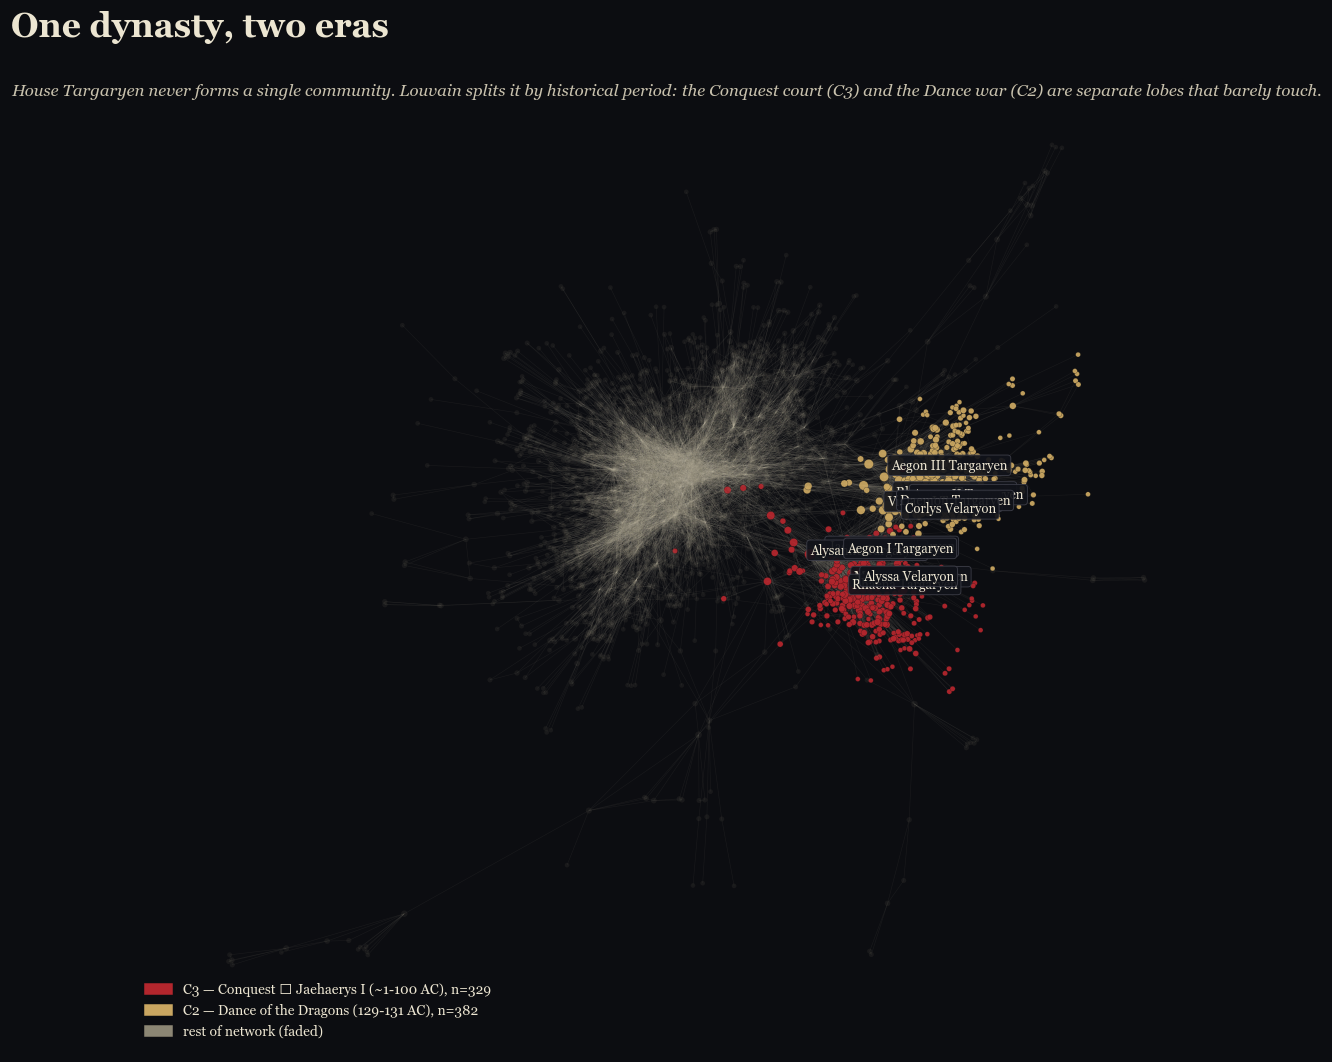

In [78]:
# --- Visualise the Targaryen era-split: C3 (Conquest) vs C2 (Dance) --------
C_CONQUEST = 3                                   # C3 — Aegon I -> Jaehaerys I
dance = (blacks | greens) & set(LCC.nodes())     # (blacks/greens from earlier cell)
C_DANCE = Counter(partition[n] for n in dance).most_common(1)[0][0]   # C2

band = {C_CONQUEST: PALETTE['crimson_bright'], C_DANCE: PALETTE['gold']}
node_colors = [band.get(partition[n], PALETTE['muted']) for n in LCC.nodes()]
node_sizes  = [6 + (LCC.degree(n) ** 0.5) * 4 for n in LCC.nodes()]
node_alphas = [0.95 if partition[n] in band else 0.10 for n in LCC.nodes()]

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(LCC, pos, alpha=0.07,
                       edge_color=PALETTE['ink_soft'], width=0.4, ax=ax)
ax.scatter([pos[n][0] for n in LCC.nodes()],
           [pos[n][1] for n in LCC.nodes()],
           c=node_colors, s=node_sizes, alpha=node_alphas,
           linewidths=0.15, edgecolors=PALETTE['bg'], zorder=3)

# Label the 6 biggest hubs of each era-lobe
for c in (C_CONQUEST, C_DANCE):
    mem = [n for n in LCC.nodes() if partition[n] == c]
    for n in sorted(mem, key=lambda x: -LCC.degree(x))[:6]:
        ax.annotate(name_by_id.get(n, n).replace('_', ' '), xy=pos[n],
                    fontsize=8.5, family='serif', color=PALETTE['ink'],
                    bbox=dict(boxstyle='round,pad=0.25', fc=PALETTE['bg_alt'],
                              ec=PALETTE['line_strong'], lw=0.6, alpha=0.92),
                    zorder=5)
ax.axis('off')

legend = [
    mpatches.Patch(color=PALETTE['crimson_bright'],
        label=f'C{C_CONQUEST} — Conquest → Jaehaerys I (~1-100 AC), '
              f'n={community_sizes[C_CONQUEST]}'),
    mpatches.Patch(color=PALETTE['gold'],
        label=f'C{C_DANCE} — Dance of the Dragons (129-131 AC), '
              f'n={community_sizes[C_DANCE]}'),
    mpatches.Patch(color=PALETTE['muted'], label='rest of network (faded)'),
]
ax.legend(handles=legend, loc='lower left', fontsize=9,
          labelcolor=PALETTE['ink'], facecolor=PALETTE['bg_alt'],
          edgecolor=PALETTE['line'])
fig.subplots_adjust(top=0.93)
got_title(fig, 'One dynasty, two eras',
          'House Targaryen never forms a single community. Louvain splits it by '
          'historical period: the Conquest court (C3) and the Dance war (C2) are '
          'separate lobes that barely touch.')
save_fig(fig, 'website/figures/graph_analysis/targaryen_era_split.png')
plt.show()
